# Data Analysis — BirdCLEF+ 2026
Combines basic EDA, deeper EDA (per-class AUC, feature importance, group/recording statistics, frequency vs AUC), and dimensionality reduction (PCA cumulative variance, LR on PCA features, K-means sanity check) in a single notebook.

**Sections**
1. Load data
2. Class imbalance
3. Labels per sample
4. Feature value distribution
5. Group / recording distribution + train-test split sanity check
6. Constant-prior baseline (lower bound on AUC)
7. PCA — explained variance and 2D visualisation
8. t-SNE — local neighbourhood structure
9. Feature correlation
10. Random Forest feature-block importance
11. Per-class AUC for the best Logistic Regression
12. AUC vs class frequency
13. PCA — cumulative variance + LR-on-PCA experiment
14. (Optional) K-means clustering vs species labels

## 1. Load data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

os.makedirs('outputs', exist_ok=True)
SAVED = 'saved/'

X      = np.load(SAVED + 'X.npy',         allow_pickle=True)
Y      = np.load(SAVED + 'Y_encoded.npy', allow_pickle=True)
groups = np.load(SAVED + 'groups.npy',    allow_pickle=True)

try:
    classes = np.load(SAVED + 'classes.npy', allow_pickle=True)
except FileNotFoundError:
    classes = np.array([f'class_{i}' for i in range(Y.shape[1])])

print(f'X.shape: {X.shape}   Y.shape: {Y.shape}   groups.shape: {groups.shape}')
print(f'Feature dim = {X.shape[1]}    Num classes = {Y.shape[1]}')

X.shape: (265924, 394)   Y.shape: (265924, 206)   groups.shape: (265924,)
Feature dim = 394    Num classes = 206


## 2. Class imbalance
Two views: classes ranked by frequency, and a histogram of how many positives each class has.

Top 10 most common classes:
  class  count  frequency
coffal1   7334   0.027579
rufnig1   5112   0.019224
 bncfly   5104   0.019193
 compau   4513   0.016971
 whtdov   4457   0.016760
 trsowl   4415   0.016602
rubthr1   4274   0.016072
gycwor1   4163   0.015655
undtin1   4036   0.015177
 roahaw   3994   0.015019

Top 10 rarest classes:
  class  count  frequency
sptnig1     13   0.000049
 476521     13   0.000049
  70711     10   0.000038
  25214     10   0.000038
 516975      9   0.000034
  24321      6   0.000023
 209233      5   0.000019
  23150      4   0.000015
 116570      2   0.000008
  23724      2   0.000008


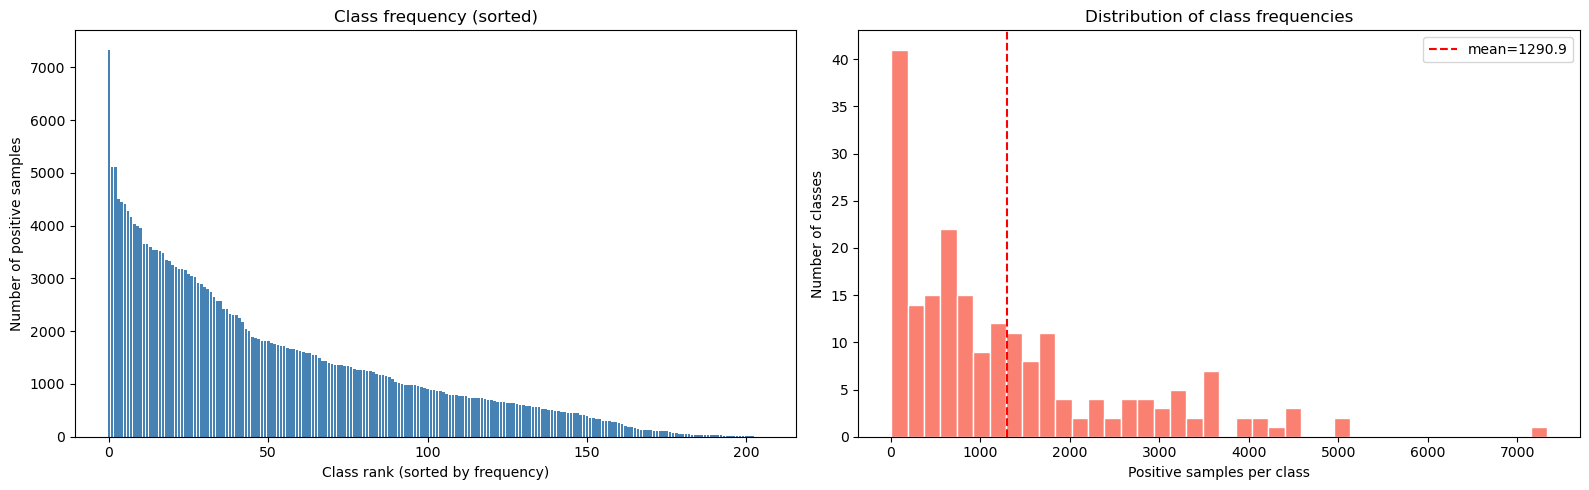


Classes with < 10 samples: 6
Imbalance ratio (max/min non-zero): 3667.0x


In [2]:
label_counts = Y.sum(axis=0)
label_freq   = label_counts / len(Y)

df_labels = pd.DataFrame({
    'class':     classes,
    'count':     label_counts.astype(int),
    'frequency': label_freq,
}).sort_values('count', ascending=False)

print('Top 10 most common classes:')
print(df_labels.head(10).to_string(index=False))
print('\nTop 10 rarest classes:')
print(df_labels.tail(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(range(len(df_labels)), df_labels['count'], color='steelblue')
axes[0].set_xlabel('Class rank (sorted by frequency)')
axes[0].set_ylabel('Number of positive samples')
axes[0].set_title('Class frequency (sorted)')

axes[1].hist(label_counts, bins=40, color='salmon', edgecolor='white')
axes[1].set_xlabel('Positive samples per class')
axes[1].set_ylabel('Number of classes')
axes[1].set_title('Distribution of class frequencies')
axes[1].axvline(label_counts.mean(), color='red', linestyle='--', label=f'mean={label_counts.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/eda_class_imbalance.png', dpi=150)
plt.show()

n_rare = (label_counts < 10).sum()
print(f'\nClasses with < 10 samples: {n_rare}')
print(f'Imbalance ratio (max/min non-zero): {label_counts[label_counts>0].max() / label_counts[label_counts>0].min():.1f}x')

## 3. Labels per sample
Most segments are single-labelled, with occasional multi-label cases for overlapping species.

Min: 1  Max: 1  Mean: 1.00


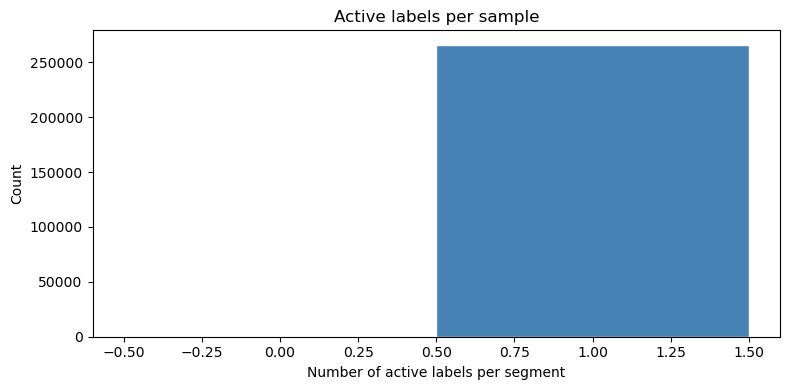

In [3]:
labels_per_sample = Y.sum(axis=1)
print(f'Min: {labels_per_sample.min()}  Max: {labels_per_sample.max()}  Mean: {labels_per_sample.mean():.2f}')

plt.figure(figsize=(8, 4))
plt.hist(labels_per_sample, bins=np.arange(labels_per_sample.max() + 2) - 0.5, color='steelblue', edgecolor='white')
plt.xlabel('Number of active labels per segment')
plt.ylabel('Count')
plt.title('Active labels per sample')
plt.tight_layout()
plt.show()

## 4. Feature value distribution
Basic statistics on the raw feature matrix. Wide range across columns is expected (mel-dB scale vs unitless statistics) — this is why we standardise before any linear model.

X stats — mean: 27.301   std: 458.979   min: -1131.371   max: 14969.499


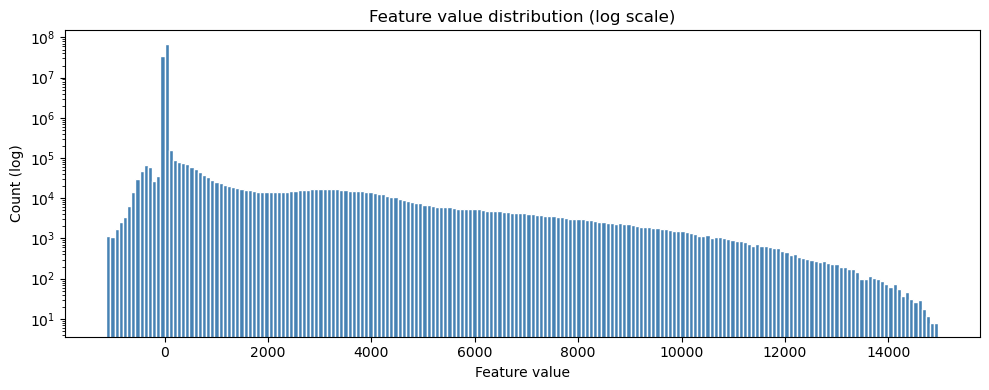

In [4]:
print(f'X stats — mean: {np.mean(X):.3f}   std: {np.std(X):.3f}   min: {np.min(X):.3f}   max: {np.max(X):.3f}')

plt.figure(figsize=(10, 4))
plt.hist(X.flatten(), bins=200, color='steelblue', edgecolor='white')
plt.yscale('log')
plt.title('Feature value distribution (log scale)')
plt.xlabel('Feature value')
plt.ylabel('Count (log)')
plt.tight_layout()
plt.show()

## 5. Group / recording distribution + split sanity check
Segments from the same recording are NOT independent. We use `GroupShuffleSplit` with the recording filename as group, and confirm there is zero overlap.

Unique recordings: 35549
Segments per recording — min:1   max:1377   mean:7.5
Outliers (>100 segments): 54 recordings
95th percentile: 21 segments


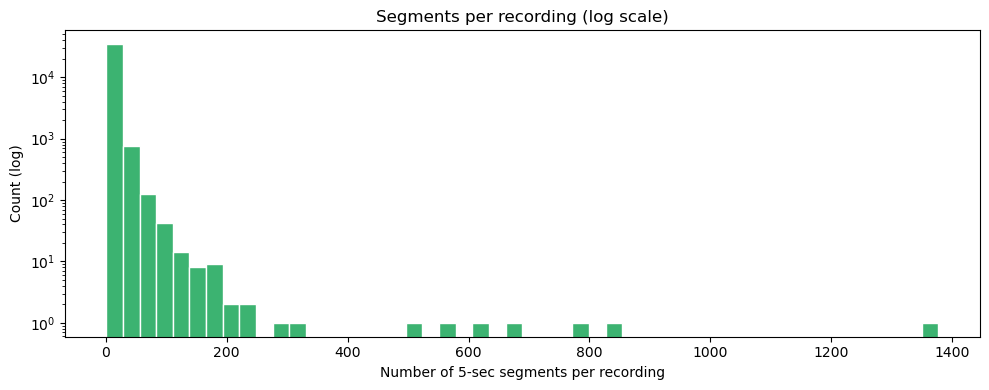


Train segments: 211720   Test segments: 54204
Train groups:   28439   Test groups:   7110
Overlapping groups (must be 0): 0


In [5]:
unique_groups, group_counts = np.unique(groups, return_counts=True)
print(f'Unique recordings: {len(unique_groups)}')
print(f'Segments per recording — min:{group_counts.min()}   max:{group_counts.max()}   mean:{group_counts.mean():.1f}')
print(f'Outliers (>100 segments): {(group_counts > 100).sum()} recordings')
print(f'95th percentile: {np.percentile(group_counts, 95):.0f} segments')

# Log-scale histogram so outliers don't crush the rest
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(group_counts, bins=50, color='mediumseagreen', edgecolor='white')
ax.set_yscale('log')
ax.set_xlabel('Number of 5-sec segments per recording')
ax.set_ylabel('Count (log)')
ax.set_title('Segments per recording (log scale)')
plt.tight_layout()
plt.savefig('outputs/eda_group_distribution.png', dpi=150)
plt.show()

# Group-aware split + leakage check
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups))
train_groups = set(groups[train_idx])
test_groups  = set(groups[test_idx])
overlap = train_groups & test_groups
print(f'\nTrain segments: {len(train_idx)}   Test segments: {len(test_idx)}')
print(f'Train groups:   {len(train_groups)}   Test groups:   {len(test_groups)}')
print(f'Overlapping groups (must be 0): {len(overlap)}')

## 6. Constant-prior baseline
Predicting the training prior for every test sample gives the AUC floor (should be ≈0.5).

In [6]:
X_train, X_test = X[train_idx], X[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]

prior = Y_train.mean(axis=0)
Y_pred_baseline = np.tile(prior, (len(Y_test), 1))

baseline_aucs = [
    roc_auc_score(Y_test[:, i], Y_pred_baseline[:, i])
    for i in range(Y_test.shape[1])
    if len(np.unique(Y_test[:, i])) > 1
]
baseline_auc = float(np.mean(baseline_aucs)) if baseline_aucs else 0.5
print(f'Constant-prior baseline AUC: {baseline_auc:.4f}   (scored over {len(baseline_aucs)} classes)')

Constant-prior baseline AUC: 0.5000   (scored over 195 classes)


## 7. PCA — explained variance and 2D visualisation

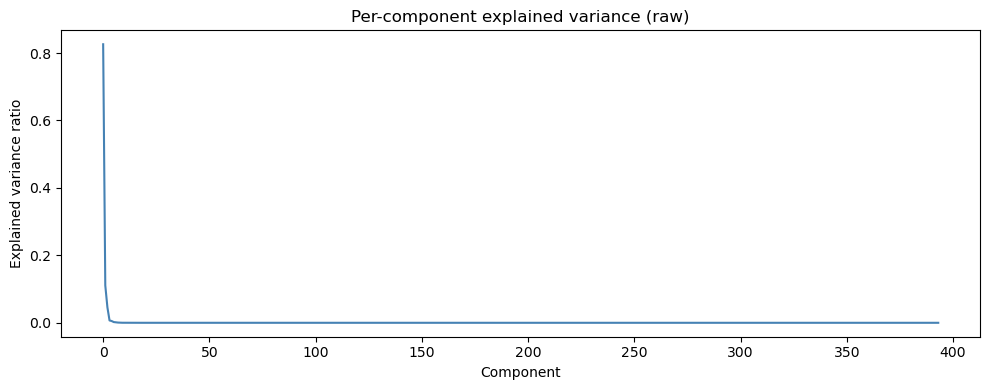

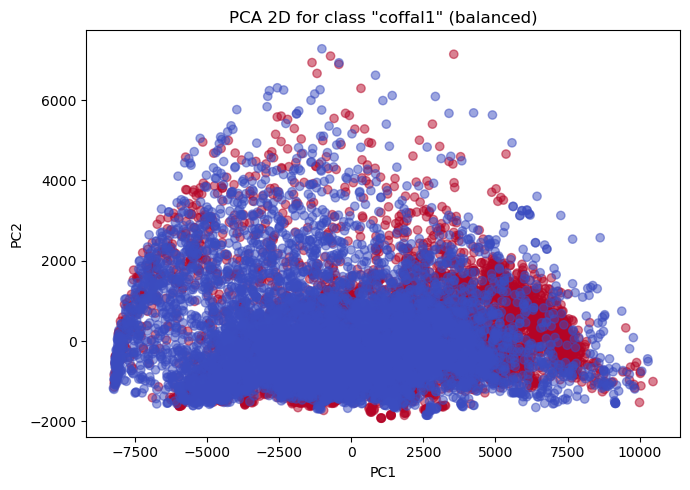

In [7]:
pca = PCA()
pca.fit(X)

plt.figure(figsize=(10, 4))
plt.plot(pca.explained_variance_ratio_, color='steelblue')
plt.xlabel('Component')
plt.ylabel('Explained variance ratio')
plt.title('Per-component explained variance (raw)')
plt.tight_layout()
plt.show()

# 2D projection on the most common class — balance pos/neg for visibility
label_id = int(np.argmax(label_counts))
mask = Y[:, label_id] == 1
idx_pos = np.where(mask)[0]
idx_neg = np.where(~mask)[0][:len(idx_pos)]
idx = np.concatenate([idx_pos, idx_neg])

X_pca2 = PCA(n_components=2).fit_transform(X[idx])
plt.figure(figsize=(7, 5))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=Y[idx, label_id], alpha=0.5, cmap='coolwarm')
plt.title(f'PCA 2D for class "{classes[label_id]}" (balanced)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

## 8. t-SNE
t-SNE on a 1000-sample subset to inspect local neighbourhood structure for the most common class.

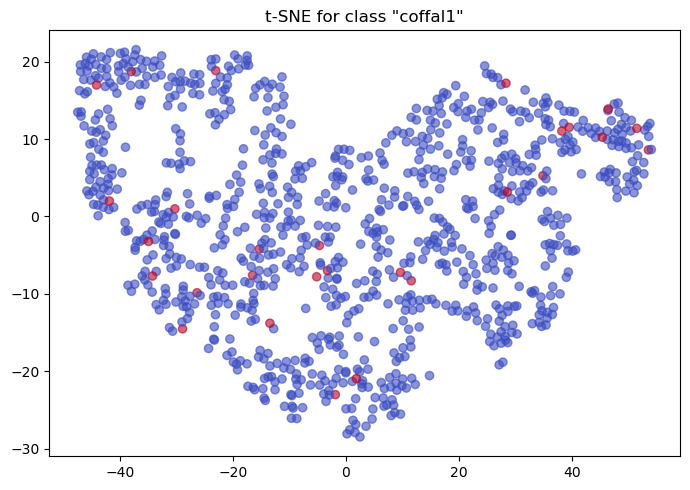

In [8]:
rng = np.random.RandomState(42)
idx = rng.choice(len(X), size=1000, replace=False)
X_sample = X[idx]
Y_sample = Y[idx]

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_sample)
label_id = int(np.argmax(Y.sum(axis=0)))

plt.figure(figsize=(7, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=Y_sample[:, label_id], cmap='coolwarm', alpha=0.6)
plt.title(f't-SNE for class "{classes[label_id]}"')
plt.tight_layout()
plt.show()

## 9. Feature correlation
Reveals block redundancy — especially within the mel-spectrogram (256 dims) and MFCC blocks.

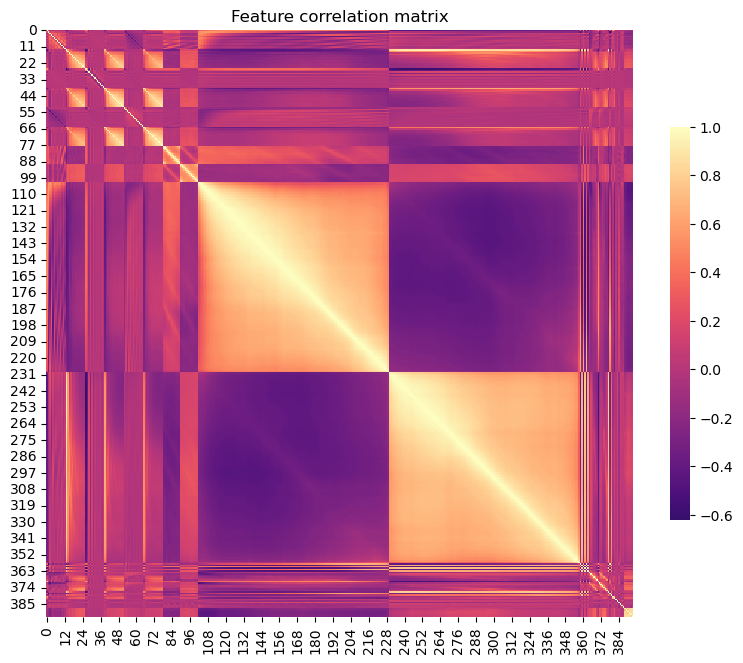

In [9]:
corr = np.corrcoef(X.T)
plt.figure(figsize=(8, 7))
sns.heatmap(corr, cmap='magma', center=0, square=True, cbar_kws={'shrink': 0.6})
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('outputs/eda_correlation.png', dpi=150)
plt.show()

## 10. Random Forest feature-block importance
Fit a small RF on the most common class and sum importance per feature block.

Training RF on class 74 (coffal1) ...


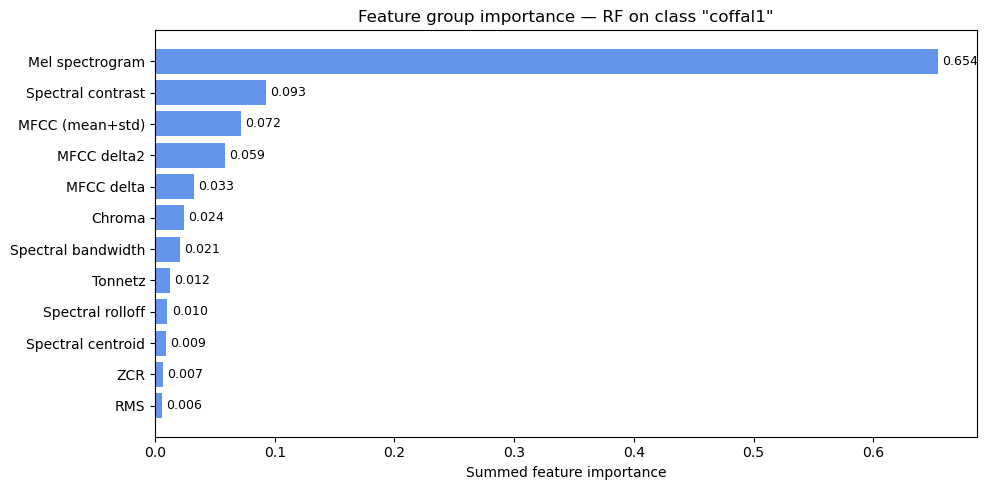

In [10]:
label_id = int(np.argmax(Y_train.sum(axis=0)))
print(f'Training RF on class {label_id} ({classes[label_id]}) ...')

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, Y_train[:, label_id])
importances = rf.feature_importances_

FEATURE_BLOCKS = [
    ('MFCC (mean+std)',       26),
    ('MFCC delta',            26),
    ('MFCC delta2',           26),
    ('Chroma',                24),
    ('Mel spectrogram',      256),
    ('Spectral centroid',      2),
    ('Spectral bandwidth',     2),
    ('Spectral rolloff',       2),
    ('Spectral contrast',     14),
    ('ZCR',                    2),
    ('RMS',                    2),
    ('Tonnetz',               12),
]

block_names, block_imp = [], []
ix = 0
for name, dim in FEATURE_BLOCKS:
    if ix + dim <= len(importances):
        block_names.append(name)
        block_imp.append(importances[ix:ix+dim].sum())
        ix += dim

df_imp = pd.DataFrame({'feature': block_names, 'importance': block_imp}).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_imp['feature'], df_imp['importance'], color='cornflowerblue')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlabel('Summed feature importance')
ax.set_title(f'Feature group importance — RF on class "{classes[label_id]}"')
plt.tight_layout()
plt.savefig('outputs/eda_feature_importance.png', dpi=150)
plt.show()

## 11. Per-class AUC — Logistic Regression (best params)

Evaluable classes: 195/206

10 hardest classes:
  class      auc
  70711 0.317198
  74580 0.441216
  22961 0.505101
nacnig1 0.602501
 yebcar 0.629694
  43435 0.667878
 redjun 0.694013
 555123 0.695757
sobcac1 0.696553
  22956 0.723046

10 easiest classes:
  class      auc
scther1 0.983499
 244024 0.984191
rufnig1 0.986983
 476521 0.987723
  22983 0.987940
  22930 0.991076
1161364 0.993366
  64898 0.993893
  65380 0.998485
  67107 0.999949


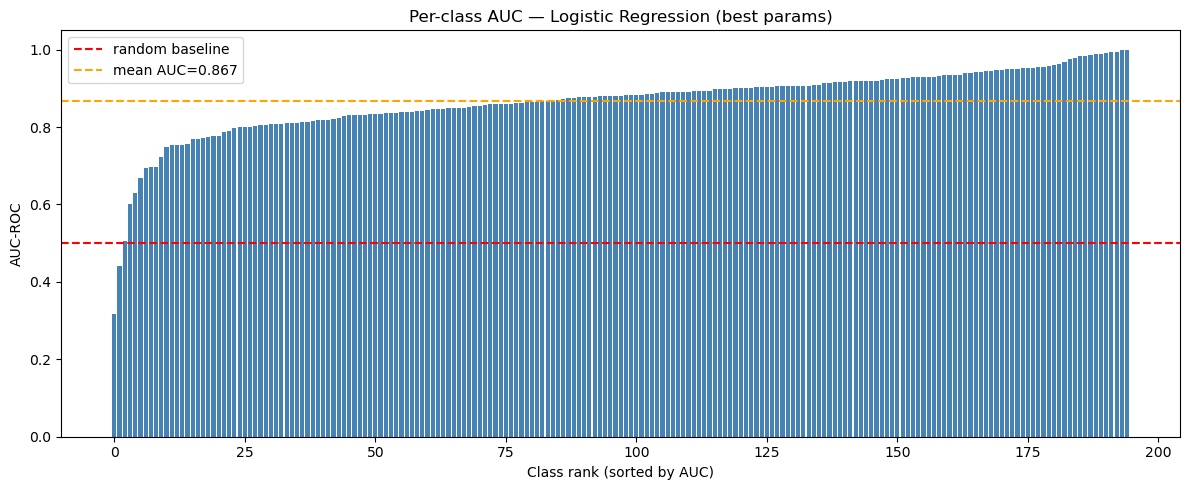

In [11]:
scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)
Xte = scaler.transform(X_test)

valid = [i for i in range(Y_train.shape[1]) if len(np.unique(Y_train[:, i])) > 1]

lr = MultiOutputClassifier(LogisticRegression(C=0.01, max_iter=10000), n_jobs=-1)
lr.fit(Xtr, Y_train[:, valid])

proba_list = lr.predict_proba(Xte)
Y_pred_v = np.stack([
    p[:, 1] if p.shape[1] > 1 else np.zeros(p.shape[0])
    for p in proba_list
], axis=1)

per_class_auc = {}
for j, i in enumerate(valid):
    if len(np.unique(Y_test[:, i])) > 1:
        per_class_auc[classes[i]] = roc_auc_score(Y_test[:, i], Y_pred_v[:, j])

df_auc = pd.DataFrame(list(per_class_auc.items()), columns=['class', 'auc']).sort_values('auc')

print(f'Evaluable classes: {len(df_auc)}/{Y.shape[1]}')
print('\n10 hardest classes:')
print(df_auc.head(10).to_string(index=False))
print('\n10 easiest classes:')
print(df_auc.tail(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(df_auc)), df_auc['auc'].values, color='steelblue')
ax.axhline(0.5, color='red', linestyle='--', label='random baseline')
ax.axhline(df_auc['auc'].mean(), color='orange', linestyle='--',
           label=f'mean AUC={df_auc["auc"].mean():.3f}')
ax.set_xlabel('Class rank (sorted by AUC)')
ax.set_ylabel('AUC-ROC')
ax.set_title('Per-class AUC — Logistic Regression (best params)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/eda_per_class_auc.png', dpi=150)
plt.show()

## 12. AUC vs class frequency
Tests whether rare classes systematically underperform. Reports Pearson $\rho$.

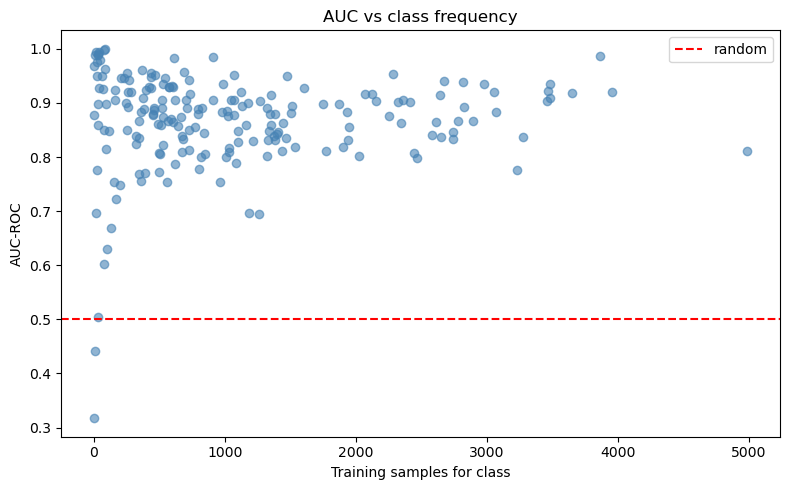

Pearson correlation (count vs AUC): 0.088


In [12]:
df_auc['count'] = [
    int(Y_train[:, np.where(classes == c)[0][0]].sum()) if c in classes else 0
    for c in df_auc['class']
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_auc['count'], df_auc['auc'], alpha=0.6, color='steelblue')
ax.set_xlabel('Training samples for class')
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC vs class frequency')
ax.axhline(0.5, color='red', linestyle='--', label='random')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/eda_auc_vs_frequency.png', dpi=150)
plt.show()

pearson = df_auc[['count', 'auc']].corr().iloc[0, 1]
print(f'Pearson correlation (count vs AUC): {pearson:.3f}')

## 13. PCA — cumulative variance + LR-on-PCA experiment
How many components do we need? Does PCA preprocessing hurt classification, or help?

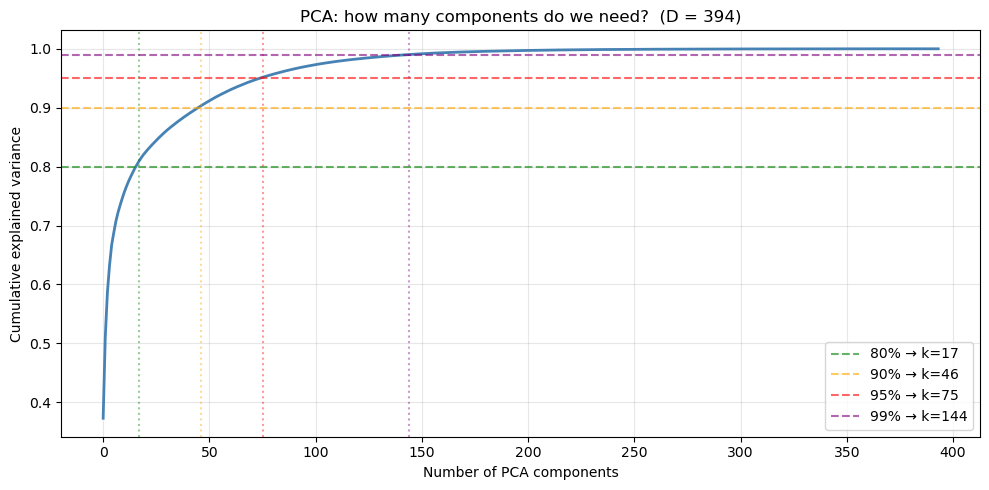


Variance thresholds → components needed:
  50% variance →   2 components (0.5% of original)
  80% variance →  17 components (4.3% of original)
  90% variance →  46 components (11.7% of original)
  95% variance →  75 components (19.0% of original)
  99% variance → 144 components (36.5% of original)


In [13]:
# Center + scale, otherwise the mel block dominates
scaler_all = StandardScaler()
Xs = scaler_all.fit_transform(X)

pca_full = PCA().fit(Xs)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cumvar, lw=2, color='steelblue')
for thresh, color in [(0.80, 'green'), (0.90, 'orange'), (0.95, 'red'), (0.99, 'purple')]:
    n = int(np.argmax(cumvar >= thresh) + 1)
    ax.axhline(thresh, ls='--', color=color, alpha=0.6, label=f'{int(thresh*100)}% → k={n}')
    ax.axvline(n, ls=':', color=color, alpha=0.4)
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title(f'PCA: how many components do we need?  (D = {X.shape[1]})')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/eda_pca_cumvar.png', dpi=150)
plt.show()

print('\nVariance thresholds → components needed:')
for thresh in [0.50, 0.80, 0.90, 0.95, 0.99]:
    n = int(np.argmax(cumvar >= thresh) + 1)
    print(f'  {int(thresh*100):2d}% variance → {n:3d} components ({100*n/X.shape[1]:.1f}% of original)')

  k=  10   variance= 74.6%   AUC=0.7600   scored 195 classes
  k=  25   variance= 84.1%   AUC=0.8126   scored 195 classes
  k=  50   variance= 91.0%   AUC=0.8334   scored 195 classes
  k= 100   variance= 97.3%   AUC=0.8577   scored 195 classes
  k= 200   variance= 99.7%   AUC=0.8689   scored 195 classes
  k= 394   variance=100.0%   AUC=0.8627   scored 195 classes


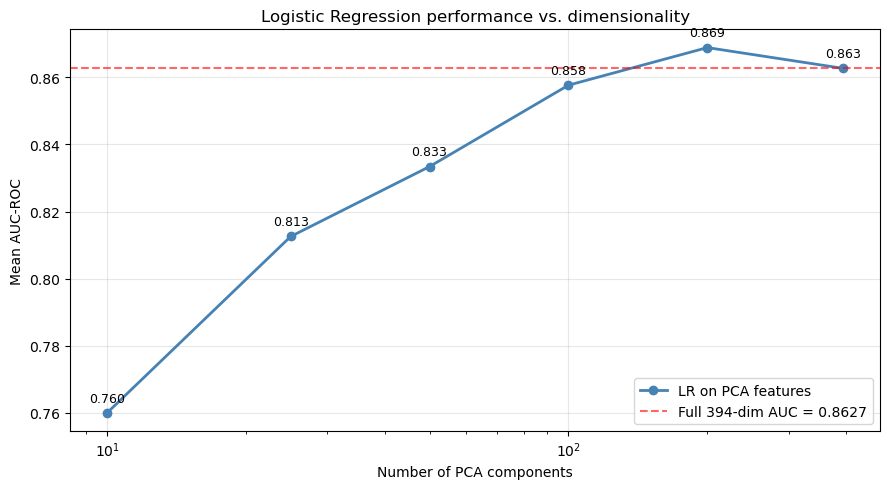

In [14]:
# LR on PCA-reduced features
Xs_train = scaler_all.transform(X[train_idx])
Xs_test  = scaler_all.transform(X[test_idx])

valid = [i for i in range(Y_train.shape[1]) if len(np.unique(Y_train[:, i])) > 1]

ks = [10, 25, 50, 100, 200, X.shape[1]]
lr_results = []

for k in ks:
    if k < X.shape[1]:
        pca_k = PCA(n_components=k, random_state=42)
        Xtr_k = pca_k.fit_transform(Xs_train)
        Xte_k = pca_k.transform(Xs_test)
        var_ratio = pca_k.explained_variance_ratio_.sum()
    else:
        Xtr_k, Xte_k = Xs_train, Xs_test
        var_ratio = 1.0

    lr_k = MultiOutputClassifier(LogisticRegression(C=0.01, max_iter=500), n_jobs=-1)
    lr_k.fit(Xtr_k, Y_train[:, valid])

    proba = lr_k.predict_proba(Xte_k)
    Y_pred = np.stack([p[:, 1] if p.shape[1] > 1 else np.zeros(p.shape[0]) for p in proba], axis=1)

    aucs = [
        roc_auc_score(Y_test[:, vi], Y_pred[:, j])
        for j, vi in enumerate(valid)
        if len(np.unique(Y_test[:, vi])) > 1
    ]
    auc = float(np.mean(aucs))
    lr_results.append({'k': k, 'variance_kept': var_ratio, 'auc': auc, 'n_scored': len(aucs)})
    print(f'  k={k:4d}   variance={var_ratio*100:5.1f}%   AUC={auc:.4f}   scored {len(aucs)} classes')

df_pca = pd.DataFrame(lr_results)
df_pca.to_csv('outputs/lr_pca_results.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_pca['k'], df_pca['auc'], marker='o', lw=2, color='steelblue', label='LR on PCA features')
auc_full = df_pca[df_pca['k'] == X.shape[1]]['auc'].values[0]
ax.axhline(auc_full, ls='--', color='red', alpha=0.6, label=f'Full {X.shape[1]}-dim AUC = {auc_full:.4f}')
for _, row in df_pca.iterrows():
    ax.annotate(f'{row["auc"]:.3f}', xy=(row['k'], row['auc']),
                xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Mean AUC-ROC')
ax.set_title('Logistic Regression performance vs. dimensionality')
ax.set_xscale('log')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/eda_pca_vs_auc.png', dpi=150)
plt.show()

## 14. (Optional) K-means clustering vs species labels
Sanity check: do the features cluster meaningfully without labels? With 206 species, a small but non-zero NMI is the expected outcome.

In [15]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X), size=min(30000, len(X)), replace=False)

X_sample_pca = PCA(n_components=50, random_state=42).fit_transform(scaler_all.transform(X[sample_idx]))

n_clusters = Y.shape[1]
print(f'Running K-means with k={n_clusters} on {X_sample_pca.shape[0]} samples (50-dim PCA)...')
km = KMeans(n_clusters=n_clusters, n_init=5, random_state=42)
clusters = km.fit_predict(X_sample_pca)

y_dom = Y[sample_idx].argmax(axis=1)
nmi = normalized_mutual_info_score(y_dom, clusters)
ari = adjusted_rand_score(y_dom, clusters)
print(f'\nNormalized Mutual Information: {nmi:.3f}')
print(f'Adjusted Rand Index:           {ari:.3f}')

Running K-means with k=206 on 30000 samples (50-dim PCA)...

Normalized Mutual Information: 0.226
Adjusted Rand Index:           0.026
